In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
from scipy.ndimage import uniform_filter1d
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup
from tqdm.notebook import tqdm

In [10]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [11]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c42 = get_patch_fs_metadata(metadata_dir, 42)
patch_fs_c14 = get_patch_fs_metadata(metadata_dir, 14)

patch_fs = {'c42':patch_fs_c42, 'c14':patch_fs_c14}


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [18]:
patch_c14 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c14patch_filt.npy'
#get cell number 
cell_num = 'c14'


#get patch data 
patch_filt_c14 = np.load(patch_c14)
patch_c14_one_ms = float(patch_fs_c14  / 1000)
patch_times_c14 = np.arange(0, np.shape(patch_filt_c14 )[0]) / patch_c14_one_ms # in ms instead of sec


patch_channel = -patch_filt_c14


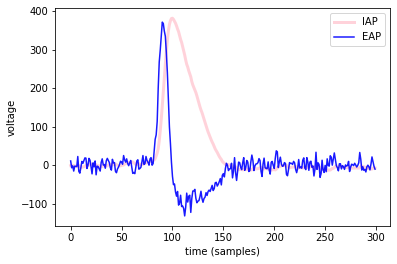

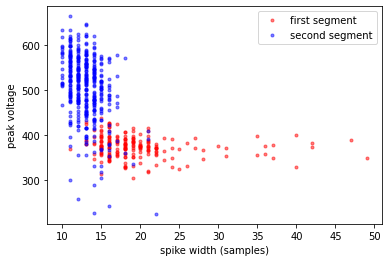

In [32]:


patch_fs = patch_fs_c14

# smooth the iap a bit, otherwise it's WAY more noisy
patch_filt = uniform_filter1d(patch_channel, size=10)

iap2eap = np.diff(patch_filt)
iap2eap = iap2eap * 10 # this is arbitrary, just to scale it better to the iap

first_segment = iap2eap[:3000000]
last_segment = iap2eap[51000000:54000000]


# show that the pseudo-eap works
plt.plot(patch_filt[21900:22200], 'pink', linewidth=3, alpha=0.7, label='IAP')
plt.plot(first_segment[21900:22200], 'b', alpha = 0.9, label='EAP')
plt.xlabel('time (samples)')
plt.ylabel('voltage')
plt.legend()
plt.show()




# function to get peaks, then get the minimum after the peak to get peak-trough duration, which is a proxy for spike-width
def find_next_minima(iap, eap, peakheight, minwin):
    peaks, peak_height = find_peaks(iap, height=peakheight, distance=minwin)
    
    # Using list comprehension to find the index of the next minimum for each peak
    next_minima_indices = [
        peak + np.argmin(eap[peak:peak + minwin]) if np.any(eap[peak:] < eap[peak]) else None
        for peak in peaks
    ]
    
    peak_height = peak_height['peak_heights']
    return peaks, next_minima_indices, peak_height

peaks_first, troughs_first, amp_first = find_next_minima(first_segment, first_segment, 200, 50)
peaks_last, troughs_last, amp_last = find_next_minima(last_segment, last_segment, 200, 50)

# plot the 2d feature space of peak voltage vs. spike width
plt.plot(troughs_first-peaks_first, amp_first, 'r.', alpha=0.5, label='first segment')
plt.plot(troughs_last-peaks_last, amp_last, 'b.', alpha=0.5, label='second segment')
plt.xlabel('spike width (samples)')
plt.ylabel('peak voltage')
plt.legend()
plt.show()

### Check how the inferred EAPs compare to the actual EAPs

In [33]:
#load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c14npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = float(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109

In [34]:
# open and load the data
npx_filt = np.load(npx_path)

npx_times = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec"""

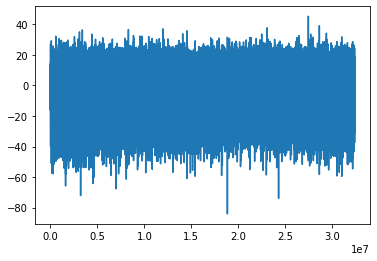

In [35]:
plt.plot(npx_filt)

In [50]:
#Run spikeparam on real EAPs 
sp_ex = Spike(thresh_amp=20, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/2529 [00:00<?, ?it/s]

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scip

 ** On entry to DLASCLS parameter number  4 had an illegal value
 ** On entry to DLASCLS parameter number  4 had an illegal value


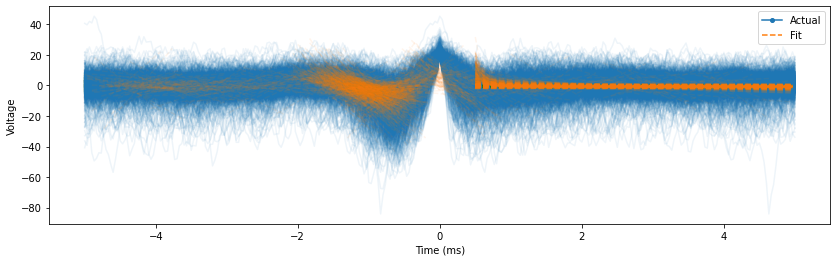

In [51]:
sp_ex.plot()

In [40]:
#Run spikeparam on inferred EAPs 

sp_ex_inf = Spike(thresh_amp=400, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex_inf.fit(iap2eap, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/4738 [00:00<?, ?it/s]

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scip

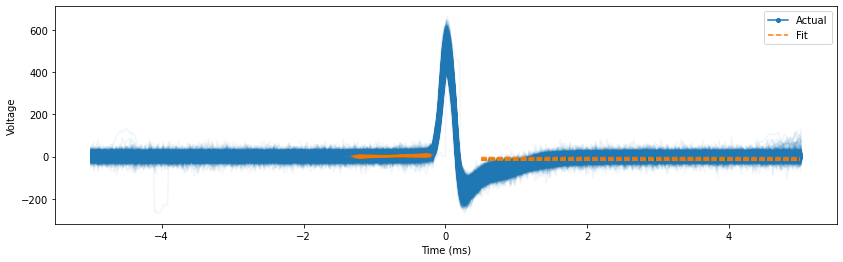

In [42]:
sp_ex_inf.plot()